# Interconnected Model

In [1]:
import pypsa
import pandas as pd

### Data Import

In [2]:
df_global = pd.read_csv("data/df_global.csv", sep=',')
df_techno = pd.read_csv("data/df_techno.csv", sep=',')

# Convert dates
df_global['utc_time'] = pd.to_datetime(df_global['utc_time'].str.strip(), dayfirst=False, errors='coerce')

## Question d:
Connect your country to at least three neighbouring countries using HVAC lines, making sure that the network includes at least one closed cycle. Look for information on the existing capacities of those interconnectors and set the capacities fixed. Assume a voltage level of 400 kV and a unitary reactance x=0.1. You can assume that the generation capacities in the neighbouring countries are fixed or co-optimise the whole system. Optimise the whole system, assuming linearised AC power flow (DC approximation) and discuss the results.

In [3]:
# Create network

network = pypsa.Network()
network.set_snapshots(df_global['utc_time'])

# Add buses (countries)

countries = ["Belgium", "France", "Netherlands", "Germany"]

for country in countries:
    network.add("Bus", country, v_nom = 400)


# Add loads

# Belgium
belgium_load = df_global.set_index("utc_time")["BE_MW"]

network.add("Load",
            "BE_load",
            bus="Belgium",
            p_set=belgium_load)

# Netherlands
Netherlands_load = df_global.set_index("utc_time")["NL_MW"]

network.add("Load",
            "NL_load",
            bus="Netherlands",
            p_set=Netherlands_load)

# France
France_load = df_global.set_index("utc_time")["FR_MW"]

network.add("Load",
            "FR_load",
            bus="France",
            p_set=France_load)

# Germany
Germany_load = df_global.set_index("utc_time")["GE_MW"]

network.add("Load",
            "GE_load",
            bus="Germany",
            p_set=Germany_load)

# Add generators


# Belgium generators: CCGT, OCGT, solar, onshore wind, offshore wind, nuclear and coal

network.add("Generator",
            "BE_CCGT",
            bus="Belgium",
            p_nom_extendable=True,
            capital_cost=df_techno.iloc[0, 1],
            marginal_cost=df_techno.iloc[0, 2])

network.add("Generator",
            "BE_OCGT",
            bus="Belgium",
            p_nom_extendable=True,
            capital_cost=df_techno.iloc[1, 1],
            marginal_cost=df_techno.iloc[1, 2])

network.add("Generator",
            "BE_solar",
            bus="Belgium",
            p_nom_extendable=True,
            capital_cost=df_techno.iloc[2, 1],
            marginal_cost=df_techno.iloc[2, 2],
            p_max_pu=df_global.set_index("utc_time")["solar_cf"])

network.add("Generator",
            "BE_onshore_wind",
            bus="Belgium",
            p_nom_extendable=True,
            capital_cost=df_techno.iloc[3, 1],
            marginal_cost=df_techno.iloc[3, 2],
            p_max_pu=df_global.set_index("utc_time")["onshore_wind_cf"])

network.add("Generator",
            "BE_offshore_wind",
            bus="Belgium",
            p_nom_extendable=True,
            capital_cost=df_techno.iloc[4, 1],
            marginal_cost=df_techno.iloc[4, 2],
            p_max_pu=df_global.set_index("utc_time")["offshore_wind_cf"])

network.add("Generator",
            "BE_nuclear",
            bus="Belgium",
            p_nom_extendable=True,
            capital_cost=df_techno.iloc[5, 1],
            marginal_cost=df_techno.iloc[5, 2])

network.add("Generator",
            "BE_coal",
            bus="Belgium",
            p_nom_extendable=True,
            capital_cost=df_techno.iloc[6, 1],
            marginal_cost=df_techno.iloc[6, 2])


# Germany generators: onshore wind, gas, coal and solar

network.add("Generator",
            "GE_wind",
            bus="Germany",
            #p_nom=15857,
            p_nom_extendable=True,
            capital_cost=df_techno.iloc[3, 1],
            marginal_cost=df_techno.iloc[3, 2],
            p_max_pu=df_global.set_index("utc_time")["onshore_wind_cf"])


network.add("Generator",
            "GE_gas",
            bus="Germany",
            #p_nom=10175,
            p_nom_extendable=True,
            capital_cost=df_techno.iloc[1, 1],
            marginal_cost=df_techno.iloc[1, 2])

network.add("Generator",
            "GE_coal",
            bus="Germany",
            #p_nom=13698,
            p_nom_extendable=True,
            capital_cost=df_techno.iloc[6, 1],
            marginal_cost=df_techno.iloc[6, 2])

network.add("Generator",
            "GE_solar",
            bus="Germany",
            #p_nom=8481,
            p_nom_extendable=True,
            capital_cost=df_techno.iloc[2, 1],
            marginal_cost=df_techno.iloc[2, 2],
            p_max_pu=df_global.set_index("utc_time")["solar_cf"])


# France generators: nuclear and onshore wind

network.add("Generator",
            "FR_nuclear",
            bus="France",
            #p_nom=43430,
            p_nom_extendable=True,
            capital_cost=df_techno.iloc[5, 1],
            marginal_cost=df_techno.iloc[5, 2])


network.add("Generator",
            "FR_wind",
            bus="France",
            #p_nom=5393,
            p_nom_extendable=True,
            capital_cost=df_techno.iloc[3, 1],
            marginal_cost=df_techno.iloc[3, 2],
            p_max_pu=df_global.set_index("utc_time")["onshore_wind_cf"])


# Netherlands generators: gas, wind, solar and coal

network.add("Generator",
            "NL_gas",
            bus="Netherlands",
            #p_nom=5055,
            p_nom_extendable=True,
            capital_cost=df_techno.iloc[1, 1],
            marginal_cost=df_techno.iloc[1, 2])


network.add("Generator",
            "NL_wind",
            bus="Netherlands",
            #p_nom=3825,
            p_nom_extendable=True,
            capital_cost=df_techno.iloc[3, 1],
            marginal_cost=df_techno.iloc[3, 2],
            p_max_pu=df_global.set_index("utc_time")["onshore_wind_cf"])


network.add("Generator",
            "NL_solar",
            bus="Netherlands",
            #p_nom=2491,
            p_nom_extendable=True,
            capital_cost=df_techno.iloc[2, 1],
            marginal_cost=df_techno.iloc[2, 2],
            p_max_pu=df_global.set_index("utc_time")["solar_cf"])


network.add("Generator",
            "NL_coal",
            bus="Netherlands",
            #p_nom=1152,
            p_nom_extendable=True,
            capital_cost=df_techno.iloc[6, 1],
            marginal_cost=df_techno.iloc[6, 2])

# Add transmission lines


# Interconnection capacities (approximate real values in MW)
interconnectors = [
    ("Belgium", "France", 3550),
    ("Belgium", "Netherlands", 3400),
    ("Belgium", "Germany", 1000),
    ("France", "Germany", 3000),
    ("Netherlands", "Germany", 3950), # ensures closed cycle
]

for bus0, bus1, capacity in interconnectors:
    network.add("Line",
                f"{bus0}-{bus1}",
                bus0=bus0,
                bus1=bus1,
                x=0.1,
                s_nom=capacity)


# Run optimization

network.optimize(solver_name="highs")


# Results

# Power flows
print(network.lines_t.p0.head())

# Generator dispatch
print(network.generators_t.p.head())

# Installed capacities (Belgium)
print(network.generators.p_nom_opt)

/var/folders/8_/lh30pz8d4z319g9vhv4z1vz00000gp/T/ipykernel_42419/725156086.py:227: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  network.optimize(solver_name="highs")
Index(['Belgium', 'France', 'Netherlands', 'Germany'], dtype='str', name='name')
Index(['Belgium-France', 'Belgium-Netherlands', 'Belgium-Germany',
       'France-Germany', 'Netherlands-Germany'],
      dtype='str', name='name')
Index(['Belgium-France', 'Belgium-Netherlands', 'Belgium-Germany',
       'France-Germany', 'Netherlands-Germany'],
      dtype='str', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 3/3 [00:00<00:00, 207.96it/s]
INFO:linopy.io: Writing time: 0.26s


Running HiGHS 1.14.0 (git hash: 7df0786): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-owm1czqi has 439217 rows; 193265 cols; 812277 nonzeros
Coefficient ranges:
  Matrix  [1e-03, 1e+00]
  Cost    [1e-02, 5e+05]
  Bound   [0e+00, 0e+00]
  RHS     [1e+03, 9e+04]
Presolving model
188596 rows, 179829 cols, 548220 nonzeros 0s
Dependent equations search running on 52704 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
188596 rows, 179829 cols, 548220 nonzeros 0s
Presolve reductions: rows 188596(-250621); columns 179829(-13436); nonzeros 548220(-264057) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0    -1.9656679136e+01 Pr: 52704(1.10771e+09) 0.6s
      33777     6.6382803259e+10 Pr: 51682(3.15426e+09); Du: 0(9.26619e-08) 5.6s
      93750     8.1899669059e+10 Pr: 44273(1.68459e+09); Du: 0(2.09839e-07) 11.3s
     101702     8.5143

INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 193265 primals, 439217 duals
Objective: 9.02e+10
Solver model: available
Solver message: Optimal




Model name          : linopy-problem-owm1czqi
Model status        : Optimal
Simplex   iterations: 166314
Objective value     :  9.0196119128e+10
P-D objective error :  1.0657927638e-14
HiGHS run time      :         87.52


INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, Line-fix-s-lower, Line-fix-s-upper, Kirchhoff-Voltage-Law were not assigned to the network.


name                       Belgium-France  Belgium-Netherlands  \
snapshot                                                         
2024-01-01 00:00:00+00:00    -2013.190312               3400.0   
2024-01-01 01:00:00+00:00    -3395.605419               3400.0   
2024-01-01 02:00:00+00:00    -3550.000000               3400.0   
2024-01-01 03:00:00+00:00    -3550.000000               3400.0   
2024-01-01 04:00:00+00:00    -3550.000000               3400.0   

name                       Belgium-Germany  France-Germany  \
snapshot                                                     
2024-01-01 00:00:00+00:00       986.809688          3000.0   
2024-01-01 01:00:00+00:00      -395.605419          3000.0   
2024-01-01 02:00:00+00:00      -550.000000          3000.0   
2024-01-01 03:00:00+00:00      -550.000000          3000.0   
2024-01-01 04:00:00+00:00      -550.000000          3000.0   

name                       Netherlands-Germany  
snapshot                                        
2024

## Question g
Assume that the countries are now also connected via gas pipelines transporting either H2 or CH4. Use
a linear approach to represent gas transport in pipelines. Optimise the network again and discuss your
results, including in the discussion which of the two energy transport networks modelled is transporting
more energy

In [4]:
# =================================================================
# TASK G: MULTI-CARRIER INTERCONNECTED MODEL (ELEC + GAS)
# =================================================================

# 1. NETWORK INITIALIZATION
network = pypsa.Network()
network.set_snapshots(df_global['utc_time'])

countries = ["Belgium", "France", "Netherlands", "Germany"]

# 2. ELECTRICITY BUSES & LOADS
for country in countries:
    network.add("Bus", country, v_nom=400)
    
    # Dynamically match the country to its load column
    load_col = {"Belgium": "BE_MW", "France": "FR_MW", "Netherlands": "NL_MW", "Germany": "GE_MW"}[country]
    network.add("Load", f"{country}_load", bus=country, p_set=df_global.set_index("utc_time")[load_col])


# 3. ORIGINAL GENERATORS (Excluding Gas, which moves to sector coupling)

# Belgium generators (Removed CCGT and OCGT)
network.add("Generator", "BE_solar", bus="Belgium", carrier="solar", p_nom_extendable=True,
            capital_cost=df_techno.iloc[2, 1], marginal_cost=df_techno.iloc[2, 2],
            p_max_pu=df_global.set_index("utc_time")["solar_cf"])

network.add("Generator", "BE_onshore_wind", bus="Belgium", carrier="onwind", p_nom_extendable=True,
            capital_cost=df_techno.iloc[3, 1], marginal_cost=df_techno.iloc[3, 2],
            p_max_pu=df_global.set_index("utc_time")["onshore_wind_cf"])

network.add("Generator", "BE_offshore_wind", bus="Belgium", carrier="offwind", p_nom_extendable=True,
            capital_cost=df_techno.iloc[4, 1], marginal_cost=df_techno.iloc[4, 2],
            p_max_pu=df_global.set_index("utc_time")["offshore_wind_cf"])

network.add("Generator", "BE_nuclear", bus="Belgium", carrier="nuclear", p_nom_extendable=True,
            capital_cost=df_techno.iloc[5, 1], marginal_cost=df_techno.iloc[5, 2])

network.add("Generator", "BE_coal", bus="Belgium", carrier="coal", p_nom_extendable=True,
            capital_cost=df_techno.iloc[6, 1], marginal_cost=df_techno.iloc[6, 2])

# Germany generators (Removed GE_gas)
network.add("Generator", "GE_wind", bus="Germany", carrier="onwind", p_nom_extendable=True,
            capital_cost=df_techno.iloc[3, 1], marginal_cost=df_techno.iloc[3, 2],
            p_max_pu=df_global.set_index("utc_time")["onshore_wind_cf"])

network.add("Generator", "GE_coal", bus="Germany", carrier="coal", p_nom_extendable=True,
            capital_cost=df_techno.iloc[6, 1], marginal_cost=df_techno.iloc[6, 2])

network.add("Generator", "GE_solar", bus="Germany", carrier="solar", p_nom_extendable=True,
            capital_cost=df_techno.iloc[2, 1], marginal_cost=df_techno.iloc[2, 2],
            p_max_pu=df_global.set_index("utc_time")["solar_cf"])

# France generators (No gas originally)
network.add("Generator", "FR_nuclear", bus="France", carrier="nuclear", p_nom_extendable=True,
            capital_cost=df_techno.iloc[5, 1], marginal_cost=df_techno.iloc[5, 2])

network.add("Generator", "FR_wind", bus="France", carrier="onwind", p_nom_extendable=True,
            capital_cost=df_techno.iloc[3, 1], marginal_cost=df_techno.iloc[3, 2],
            p_max_pu=df_global.set_index("utc_time")["onshore_wind_cf"])

# Netherlands generators (Removed NL_gas)
network.add("Generator", "NL_wind", bus="Netherlands", carrier="onwind", p_nom_extendable=True,
            capital_cost=df_techno.iloc[3, 1], marginal_cost=df_techno.iloc[3, 2],
            p_max_pu=df_global.set_index("utc_time")["onshore_wind_cf"])

network.add("Generator", "NL_solar", bus="Netherlands", carrier="solar", p_nom_extendable=True,
            capital_cost=df_techno.iloc[2, 1], marginal_cost=df_techno.iloc[2, 2],
            p_max_pu=df_global.set_index("utc_time")["solar_cf"])

network.add("Generator", "NL_coal", bus="Netherlands", carrier="coal", p_nom_extendable=True,
            capital_cost=df_techno.iloc[6, 1], marginal_cost=df_techno.iloc[6, 2])


# 4. ELECTRICITY TRANSMISSION LINES (With s_nom_extendable=False fix)
interconnectors = [
    ("Belgium", "France", 3550),
    ("Belgium", "Netherlands", 3400),
    ("Belgium", "Germany", 1000),
    ("France", "Germany", 3000),
    ("Netherlands", "Germany", 3950),
]

for bus0, bus1, capacity in interconnectors:
    network.add("Line", f"{bus0}-{bus1}", bus0=bus0, bus1=bus1, x=0.1, 
                s_nom=capacity, s_nom_extendable=False)


# 5. GAS SECTOR (Task G)
gas_prices = {"Netherlands": 35.0, "Belgium": 37.0, "Germany": 40.0, "France": 40.0}

for country in countries:
    network.add("Bus", f"{country}_gas", carrier="CH4")
    network.add("Generator", f"{country}_gas_source",
            bus=f"{country}_gas",
            carrier="CH4",   # ← CRITICAL FIX
            p_nom_extendable=True,
            marginal_cost=gas_prices[country])

# Gas Pipelines (marginal_cost=0 to prevent infinite loop glitch)
for bus0, bus1, _ in interconnectors:
    network.add("Link", f"{bus0}-{bus1}_pipeline", bus0=f"{bus0}_gas", bus1=f"{bus1}_gas",
                p_nom_extendable=True, capital_cost=4000, marginal_cost=0.0, p_min_pu=-1)

# 6. SECTOR COUPLING: CCGT Conversion Links
# Only adding CCGTs to countries that originally had them (BE, GE, NL)
ccgt_countries = ["Belgium", "Germany", "Netherlands"]
for country in ccgt_countries:
    network.add("Link", f"{country}_CCGT_conversion",
            bus0=f"{country}_gas", bus1=country,
            carrier="CH4",   # ← ensures gas usage is counted
            efficiency=0.57,
            capital_cost=df_techno.iloc[0, 1],
            p_nom_extendable=True)


# 7. OPTIMIZATION
print("Solving Multi-Carrier Model...")
network.optimize(solver_name="highs")

/var/folders/8_/lh30pz8d4z319g9vhv4z1vz00000gp/T/ipykernel_42419/1451604625.py:118: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  network.optimize(solver_name="highs")
Index(['Belgium', 'France', 'Netherlands', 'Germany', 'Belgium_gas',
       'France_gas', 'Netherlands_gas', 'Germany_gas'],
      dtype='str', name='name')
Index(['BE_solar', 'BE_onshore_wind', 'BE_offshore_wind', 'BE_nuclear',
       'BE_coal', 'GE_wind', 'GE_coal', 'GE_solar', 'FR_nuclear', 'FR_wind',
       'NL_wind', 'NL_solar', 'NL_coal', 'Belgium_gas_source',
       'France_gas_source', 'Netherlands_gas_source', 'Germany_gas_source'],
      dtype='str', name='name')
Index(['Belgium-France_pipeline', 'Belgium-Netherlands_pipeline',
       'Belgium-Germany_pipeline', 'France-Germa

Solving Multi-Carrier Model...


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 5/5 [00:00<00:00, 277.53it/s]
INFO:linopy.io: Writing time: 0.22s


Running HiGHS 1.14.0 (git hash: 7df0786): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-prbzdpz1 has 614905 rows; 263545 cols; 1207565 nonzeros
Coefficient ranges:
  Matrix  [1e-03, 1e+00]
  Cost    [1e-02, 5e+05]
  Bound   [0e+00, 0e+00]
  RHS     [1e+03, 9e+04]
Presolving model
302788 rows, 250105 cols, 846876 nonzeros 0s
Dependent equations search running on 61488 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
276436 rows, 223753 cols, 908512 nonzeros 0s
Presolve reductions: rows 276436(-338469); columns 223753(-39792); nonzeros 908512(-299053) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0    -1.9628701751e+01 Pr: 52704(1.10771e+09); Du: 0(9.99975e-09) 0.9s
      27511     4.6594101507e+10 Pr: 53050(1.17063e+09); Du: 0(1.68499e-07) 6.2s
      50369     6.4053621146e+10 Pr: 69150(9.10306e+09); Du: 0(1.59553e-07) 11.8s
 

INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 263545 primals, 614905 duals
Objective: 9.18e+10
Solver model: available
Solver message: Optimal




Model name          : linopy-problem-prbzdpz1
Model status        : Optimal
Simplex   iterations: 220022
Objective value     :  9.1776647803e+10
P-D objective error :  5.1623742175e-14
HiGHS run time      :        177.80


INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, Line-fix-s-lower, Line-fix-s-upper, Link-ext-p-lower, Link-ext-p-upper, Kirchhoff-Voltage-Law were not assigned to the network.


('ok', 'optimal')


 TASK G: TRANSPORT NETWORKS SUMMARY
Total Energy via Electricity: 94.54 TWh
Total Energy via Gas (CH4):   421.51 TWh

 TABLE 1: ELECTRICAL INSTALLED CAPACITY (MW)
carrier          CCGT  coal   nuclear  offshore_wind  onshore_wind     solar      wind
country                                                                               
Belgium      12900.82   0.0      0.00       12102.15           0.0   7904.66      0.00
France           0.00   0.0  76225.03           0.00           0.0      0.00   7759.52
Germany      67775.96   0.0      0.00           0.00           0.0  78292.07  82806.33
Netherlands  20262.77   0.0      0.00           0.00           0.0  20926.79  11971.88

 TABLE 2: ELECTRICAL ANNUAL GENERATION (TWh)
carrier        CCGT  coal  nuclear  offshore_wind  onshore_wind  solar    wind
country                                                                       
Belgium        3.13   0.0      0.0          39.48           0.0   8.28    0.00
France         0.00   0.0    47

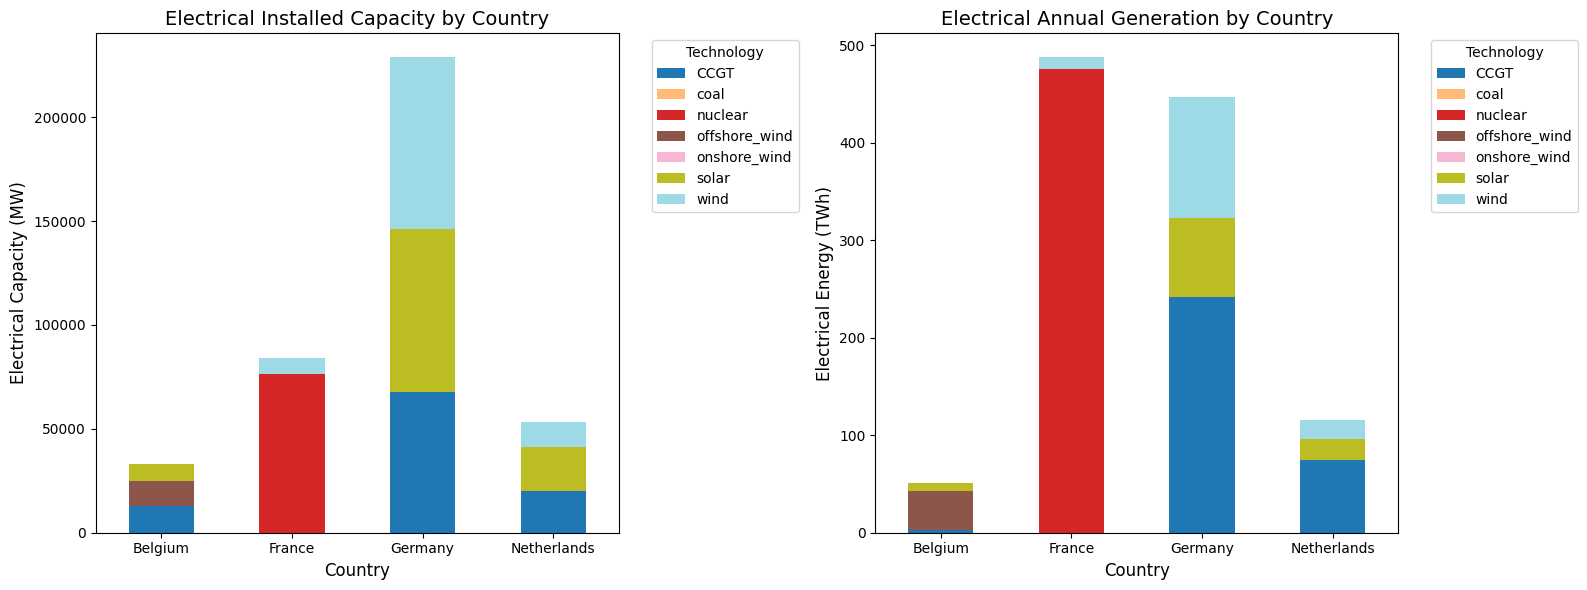


 TABLE 3: TRANSPORT NETWORKS COMPARISON
                     Elec Line Capacity (MW)  Gas Pipe Capacity (MW_th)  Total Elec Flow (TWh)  Total Gas Flow (TWh)
name                                                                                                                
Belgium-France                        3550.0                      -0.00                  27.29                  0.00
Belgium-Netherlands                   3400.0                      -0.00                  19.56                  0.00
Belgium-Germany                       1000.0                     682.25                   4.96                  2.60
France-Germany                        3000.0                      -0.00                  24.92                  0.00
Netherlands-Germany                   3950.0                   83320.14                  17.81                418.92


In [ ]:
# =================================================================
# 8. EXTENDED RESULTS ANALYSIS, TABLES & PLOTTING (ELECTRICITY FOCUSED)
# =================================================================
import matplotlib.pyplot as plt

print("\n" + "="*50)
print(" TASK G: TRANSPORT NETWORKS SUMMARY")
print("="*50)
energy_elec = network.lines_t.p0.abs().sum().sum() / 1e6
energy_gas = network.links_t.p0[[l for l in network.links.index if "pipeline" in l]].abs().sum().sum() / 1e6

print(f"Total Energy via Electricity: {energy_elec:.2f} TWh")
print(f"Total Energy via Gas (CH4):   {energy_gas:.2f} TWh")

# --- DATA EXTRACTION (FILTERED FOR ELECTRICITY GRAPHS) ---
gens = network.generators[['bus', 'p_nom_opt']].copy()

# FILTER: Remove raw gas sources so they don't distort the electricity mix graphs
gens = gens[~gens['bus'].astype(str).str.endswith('_gas')]

gens['country'] = gens['bus'].astype(str)

# Function to clean generator names
def extract_carrier(name):
    name = str(name)
    if '_' in name:
        return name.split('_', 1)[1]
    return name

gens['carrier'] = gens.index.to_series().apply(extract_carrier)

# Add Generation (converted to TWh)
gen_p = network.generators_t.p.sum()
# Only take the generation values for the filtered generators
gens['generation_twh'] = gen_p[gens.index].values / 1e6

# Safely extract CCGT links
link_idx_str = network.links.index.astype(str)
ccgt_mask = link_idx_str.str.contains('CCGT')
ccgt_names = network.links.index[ccgt_mask]

ccgt_links = network.links.loc[ccgt_names, ['bus1', 'p_nom_opt']].copy()
ccgt_links = ccgt_links.rename(columns={'bus1': 'country'})
ccgt_links['country'] = ccgt_links['country'].astype(str)
ccgt_links['carrier'] = 'CCGT'

# CONVERSION: Convert CCGT Gas intake capacity to Electrical Output capacity
ccgt_links['p_nom_opt'] = ccgt_links['p_nom_opt'] * 0.57

# CCGT Generation: Absolute flow * efficiency (0.57) converted to TWh
ccgt_gen = network.links_t.p0[ccgt_names].abs().sum() * 0.57 / 1e6
ccgt_links['generation_twh'] = ccgt_gen.values

# Combine all data
all_data = pd.concat([
    gens[['country', 'carrier', 'p_nom_opt', 'generation_twh']], 
    ccgt_links[['country', 'carrier', 'p_nom_opt', 'generation_twh']]
])

# Create Pivot Tables for Capacity and Generation
cap_mix = all_data.groupby(['country', 'carrier'])['p_nom_opt'].sum().unstack().fillna(0)
prod_mix = all_data.groupby(['country', 'carrier'])['generation_twh'].sum().unstack().fillna(0)


# --- 1. PRINT DATA TABLES ---
print("\n" + "="*50)
print(" TABLE 1: ELECTRICAL INSTALLED CAPACITY (MW)")
print("="*50)
print(cap_mix.round(2).to_string())

print("\n" + "="*50)
print(" TABLE 2: ELECTRICAL ANNUAL GENERATION (TWh)")
print("="*50)
print(prod_mix.round(2).to_string())


# --- 2. PLOT GRAPHS ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Graph 1: Capacity
cap_mix.plot(kind='bar', stacked=True, colormap='tab20', ax=ax1)
ax1.set_title('Electrical Installed Capacity by Country', fontsize=14)
ax1.set_ylabel('Electrical Capacity (MW)', fontsize=12)
ax1.set_xlabel('Country', fontsize=12)
ax1.tick_params(axis='x', rotation=0)
ax1.legend(title='Technology', bbox_to_anchor=(1.05, 1), loc='upper left')

# Graph 2: Generation
prod_mix.plot(kind='bar', stacked=True, colormap='tab20', ax=ax2)
ax2.set_title('Electrical Annual Generation by Country', fontsize=14)
ax2.set_ylabel('Electrical Energy (TWh)', fontsize=12)
ax2.set_xlabel('Country', fontsize=12)
ax2.tick_params(axis='x', rotation=0)
ax2.legend(title='Technology', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# --- 3. TRANSPORT COMPARISON TABLE ---
elec_caps = network.lines[['s_nom']].rename(columns={'s_nom': 'Elec Capacity (MW)'})
gas_caps = network.links[link_idx_str.str.contains('pipeline')][['p_nom_opt']].rename(columns={'p_nom_opt': 'Gas Capacity (MW_th)'})
gas_caps.index = gas_caps.index.astype(str).str.replace('_pipeline', '')

elec_flows = network.lines_t.p0.abs().sum() / 1e6
gas_flows = network.links_t.p0[network.links.index[link_idx_str.str.contains('pipeline')]].abs().sum() / 1e6
gas_flows.index = gas_flows.index.astype(str).str.replace('_pipeline', '')

network_comparison = pd.DataFrame({
    'Elec Line Capacity (MW)': elec_caps['Elec Capacity (MW)'],
    'Gas Pipe Capacity (MW_th)': gas_caps['Gas Capacity (MW_th)'],
    'Total Elec Flow (TWh)': elec_flows,
    'Total Gas Flow (TWh)': gas_flows
}).fillna(0)

print("\n" + "="*50)
print(" TABLE 3: TRANSPORT NETWORKS COMPARISON")
print("="*50)
print(network_comparison.round(2).to_string())

## Question h
Select one target for decarbonisation (i.e., one CO2 allowance limit). What is the (global/system-wide)
CO2 price required to achieve that decarbonisation level? Search for information on the existing CO2
tax in your countries (if any) and discuss your results. Is the model in agreement with the existing
CO2 tax (either national CO2 tax and/or the European CO2 price coming from the ETS)? Why or
why not?

In [6]:
#Add the CO2 contraints 
carriers = df_techno.index.tolist()

for c in carriers:
    tech_name = df_techno.technology[c]
    co2_value = df_techno.carbon_intensity[c]
    
    network.add(
        "Carrier",
        name=tech_name,
        co2_emissions=co2_value
    )

network.add(
    "Carrier",
    name = "CH4",
    co2_emissions=0.198, #tCO2/MWh_th
)

if "co2_limit" in network.global_constraints.index:
    network.remove("GlobalConstraint", "co2_limit")
network.add("GlobalConstraint", "co2_limit",
            type="primary_energy",
            carrier_attribute="co2_emissions",
            sense="<=",
            constant=101e6)

# Re-run optimization with CO2 constraint
network.optimize(solver_name="highs")

/var/folders/8_/lh30pz8d4z319g9vhv4z1vz00000gp/T/ipykernel_42419/3852701027.py:29: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  network.optimize(solver_name="highs")
Index(['Belgium', 'France', 'Netherlands', 'Germany'], dtype='str', name='name')
Index(['Belgium-France', 'Belgium-Netherlands', 'Belgium-Germany',
       'France-Germany', 'Netherlands-Germany'],
      dtype='str', name='name')
Index(['Belgium-France', 'Belgium-Netherlands', 'Belgium-Germany',
       'France-Germany', 'Netherlands-Germany'],
      dtype='str', name='name')
Index(['0'], dtype='str', name='name')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/linopy/common.py:177: UserWarning: coords for dimension(s) ['snapshot'] is not aligned with the p

Running HiGHS 1.14.0 (git hash: 7df0786): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-ftljozm3 has 614906 rows; 263545 cols; 1356893 nonzeros
Coefficient ranges:
  Matrix  [1e-03, 1e+00]
  Cost    [1e-02, 5e+05]
  Bound   [0e+00, 0e+00]
  RHS     [1e+03, 1e+08]
Presolving model
302789 rows, 250105 cols, 982768 nonzeros 0s
Dependent equations search running on 61488 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.01s (limit = 1000.00s)
276437 rows, 223753 cols, 1044404 nonzeros 0s
Presolve reductions: rows 276437(-338469); columns 223753(-39792); nonzeros 1044404(-312489) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0    -1.9616681630e+01 Pr: 52704(1.10771e+09); Du: 0(1.00643e-08) 1.1s
      26244     4.9460830777e+10 Pr: 54117(1.35664e+09); Du: 0(2.07693e-07) 6.3s
      50745     6.8362462716e+10 Pr: 49134(7.94914e+08); Du: 0(1.60806e-07) 11.6s

INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 263545 primals, 614906 duals
Objective: 9.45e+10
Solver model: available
Solver message: Optimal




Model name          : linopy-problem-ftljozm3
Model status        : Optimal
Simplex   iterations: 349864
Objective value     :  9.4470091790e+10
P-D objective error :  1.9665034014e-13
HiGHS run time      :       1144.02


INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, Line-fix-s-lower, Line-fix-s-upper, Link-ext-p-lower, Link-ext-p-upper, Kirchhoff-Voltage-Law were not assigned to the network.


('ok', 'optimal')

In [7]:
# Calculate and print the CO2 price
co2_price = network.global_constraints.at["co2_limit", "mu"]
print(f"CO2 price: {co2_price:.2f} €/tCO2")

# --- Generator emissions ---
gen_emissions = (
    network.generators_t.p
    .multiply(network.generators.carrier.map(network.carriers.co2_emissions))
    .sum().sum()
)
# --- Link emissions (CCGT gas use) ---
ccgt_links = network.links.index[network.links.index.str.contains("CCGT")]

link_emissions = (
    network.links_t.p0[ccgt_links]
    .sum()
    * network.carriers.at["CH4", "co2_emissions"]
)

link_emissions = 0

total_emissions = gen_emissions + link_emissions

print(f"Total emissions: {total_emissions/1e6:.2f} MtCO2")

CO2 price: -181.66 €/tCO2
Total emissions: 101.00 MtCO2


## Question i
Connect the electricity sector with, at least another sector (e.g. heating or transport), and co-optimise
all the sectors.

In [11]:
#Data import for the heating load
data_heat = pd.read_csv('data/heat_demand.csv',sep=';')
data_heat['utc_time'] = pd.to_datetime(data_heat['utc_time'].str.strip(), dayfirst=False, errors='coerce')
data_heat['utc_time'] = data_heat['utc_time'] + pd.DateOffset(years=9)

data_heat.index = pd.DatetimeIndex(data_heat['utc_time'])

In [ ]:
# 1. NETWORK INITIALIZATION
n = pypsa.Network()
n.set_snapshots(df_global['utc_time'])

countries = [BEL, FRA, NLD, DEU]

# 2. ELECTRICITY BUSES & LOADS
for country in countries:
    n.add("Bus", f"{country}_elec", v_nom=400)
    
    # Dynamically match the country to its load column
    load_col = {BEL: "BE_MW", FRA: "FR_MW", NLD: "NL_MW", DEU: "GE_MW"}[country]
    n.add("Load", f"{country}_electricity_demand", bus=f"{country}_elec", p_set=df_global.set_index("utc_time")[load_col])

# 2. HEAT BUSES & LOADS
for country in countries:
    n.add("Bus", f"{country}_heat")
    n.add("Load", f"{country}_heat_demand", bus=f"{country}_heat", p_set=data_heat.set_index("utc_time")[country])

## Question j 
Finally, select one topic that is under discussion in your region. Design and implement an experiment
to obtain relevant information regarding that topic